In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import pandas as pd
titanic_df = pd.read_csv("/content/drive/MyDrive/dsml12/titanic-data.csv")

In [63]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
titanic_df.groupby("Embarked")["Fare"].transform("mean")

# mean_ages = titanic_df_2.groupby("Sex")["Age"].transform("mean")

,Fare
0,27.079812
1,59.954144
2,27.079812
3,27.079812
4,27.079812
...,...
886,27.079812
887,27.079812
888,27.079812
889,59.954144


In [65]:
titanic_df.groupby(["Fare","Age"]).sum()

PassengerId  Survived  Pclass  \
Fare     Age                                   
0.0000   19.0          303         0       3   
         25.0          272         1       3   
         36.0          180         0       3   
         38.0          823         0       1   
         39.0          807         0       1   
...                    ...       ...     ...   
263.0000 23.0           89         1       1   
         24.0          342         1       1   
         64.0          439         0       1   
512.3292 35.0          997         2       2   
         36.0          680         1       1   

                                                 Name         Sex  SibSp  \
Fare     Age                                                               
0.0000   19.0         Johnson, Mr. William Cahoone Jr        male      0   
         25.0            Tornquist, Mr. William Henry        male      0   
         36.0                     Leonard, Mr. Lionel        male      0   
         38.0         Reuchlin, Jonkheer. John George        male      0   
         39.0                  Andrews, Mr. Thomas Jr        male      0   
...                                               ...         ...    ...   
263.0000 23.0              Fortune, Miss. Mabel Helen      female      3   
         24.0          Fortune, Miss. Alice Elizabeth      female      3   
         64.0                       Fortune, Mr. Mark        male      1   
512.3292 35.0  Ward, Miss. AnnaLesurer, Mr. Gustave J  femalemale      0   
         36.0      Cardeza, Mr. Thomas Drake Martinez        male      0   

               Parch            Ticket        Cabin Embarked  
Fare     Age                                                  
0.0000   19.0      0              LINE            0        S  
         25.0      0              LINE            0        S  
         36.0      0              LINE            0        S  
         38.0      0             19972            0        S  
         39.0      0            112050          A36        S  
...              ...               ...          ...      ...  
263.0000 23.0      2             19950  C23 C25 C27        S  
         24.0      2             19950  C23 C25 C27        S  
         64.0      4             19950  C23 C25 C27        S  
512.3292 35.0      0  PC 17755PC 17755         B101       CC  
         36.0      1          PC 17755  B51 B53 B55        C  

[638 rows x 10 columns]

In [66]:
# Pandas method chaining

titles = titanic_df['Name'].str.split(',')
titanic_df['Title'] = titles.str[1].str.strip().str.split(' ').str[0]
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.


In [67]:
# Cleaing Duplicates

titanic_df[titanic_df.duplicated(subset="Embarked")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr.
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev.
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss.
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss.
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr.


In [68]:
titanic_df.drop_duplicates(subset="Sex",inplace=True)
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.


In [69]:
# Data management
# Type conversion

# dataframe.astype()

In [70]:
titanic_df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [71]:
titanic_df.Fare.astype("int")

,Fare
0,7
1,71


In [72]:
titanic_df_changed = titanic_df.astype(
    {"Survived": bool, "Fare":int}
)
titanic_df_changed.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7,NaN,S,Mr.
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71,C85,C,Mrs.


In [73]:
# insert, deleting row/column,
# fillna, isna, removing null value, imputation, drop_duplication , type changing, IQR

In [74]:
titanic_df.index

Index([0, 1], dtype='int64')

In [75]:
titanic_df.index = titanic_df.PassengerId.astype(str) + "_skill"

In [76]:
titanic_df.index

Index(['1_skill', '2_skill'], dtype='object', name='PassengerId')

In [77]:
titanic_df.loc["1_skill"]

,1_skill
PassengerId,1
Survived,0
Pclass,3
Name,"Braund, Mr. Owen Harris"
Sex,male
Age,22.0
SibSp,1
Parch,0
Ticket,A/5 21171
Fare,7.25


In [78]:
titanic_df = titanic_df.set_index("PassengerId")
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.


In [79]:
# titanic_df.drop([2,5,8,66,300], axis=0, inplace=True)

In [80]:
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.


In [81]:
titanic_df.reset_index(drop = True)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.


In [82]:
# Indexing

# get index -> dataframe.index

# set index -> dataframe.index = Sequence or Series

# reset index -> datafraem.reset_index

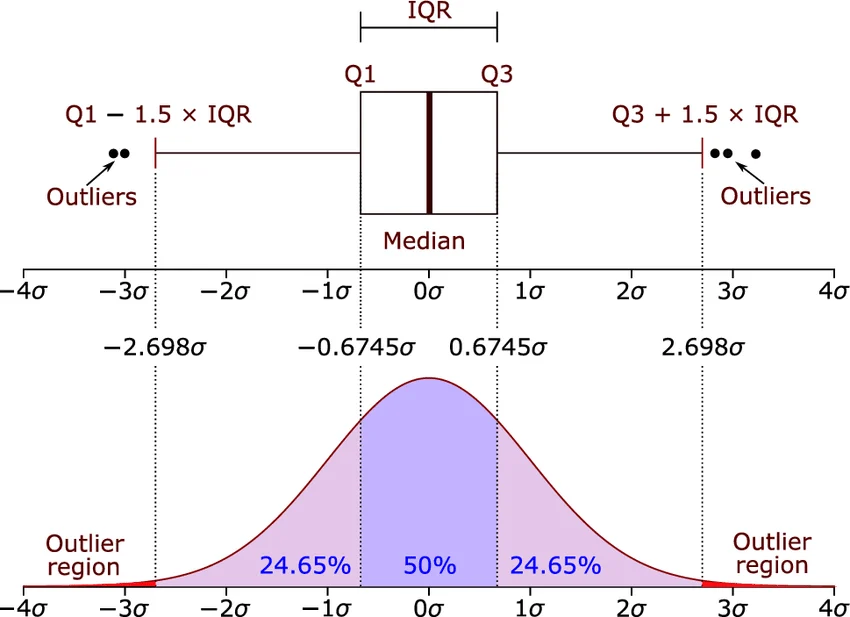

In [83]:
# Using IQR
# Interquatile Range

<Axes: >

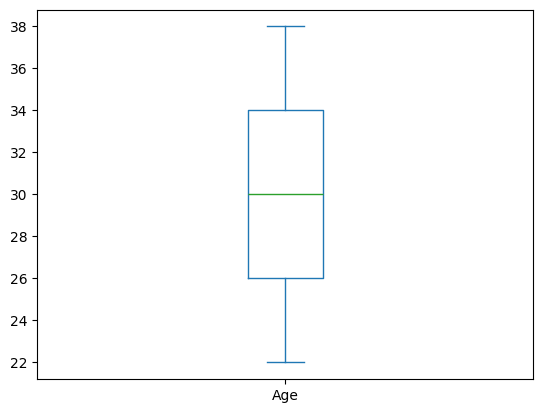

In [84]:
titanic_df.Age.plot.box()

In [85]:
Q1 = titanic_df.Age.quantile(q=0.25)
Q3 = titanic_df.Age.quantile(q=0.75)

In [86]:
IQR = Q3 -Q1
IQR

np.float64(8.0)

In [87]:
upper_limit = Q3 + 1.5 * IQR
upper_limit

np.float64(46.0)

In [88]:
lower_limit = Q1 - 1.5 * IQR
lower_limit

np.float64(14.0)

In [89]:
titanic_df[(titanic_df.Age > upper_limit) | (titanic_df.Age < lower_limit)]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,


In [90]:
titanic_df_outlier_free = titanic_df[(titanic_df.Age < upper_limit) | (titanic_df.Age > lower_limit)]
titanic_df_outlier_free

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.


In [91]:
titanic_df_outlier_free

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.


In [92]:
import numpy as np
from scipy import stats

b = np.array([120, 122, 118, 130, 125, 128, 115, 121, 123, 119])
a = np.array([115, 120, 112, 128, 122, 125, 110, 117, 119, 114])

alpha = 0.05

t_stat, p_val = stats.ttest_rel(a, b)

m = np.mean(a - b)
s = np.std(a - b, ddof=1)
n = len(b)
t_manual = m / (s / np.sqrt(n))

decision = "Reject" if p_val <= alpha else "Fail to reject"
concl = "Significant difference." if decision == "Reject" else "No significant difference."

print("T:", t_stat)
print("P:", p_val)
print("T manual:", t_manual)
print(f"Decision: {decision} H0 at α={alpha}")
print("Conclusion:", concl)

T: -9.0
P: 8.538051223166285e-06
T manual: -9.0
Decision: Reject H0 at α=0.05
Conclusion: Significant difference.


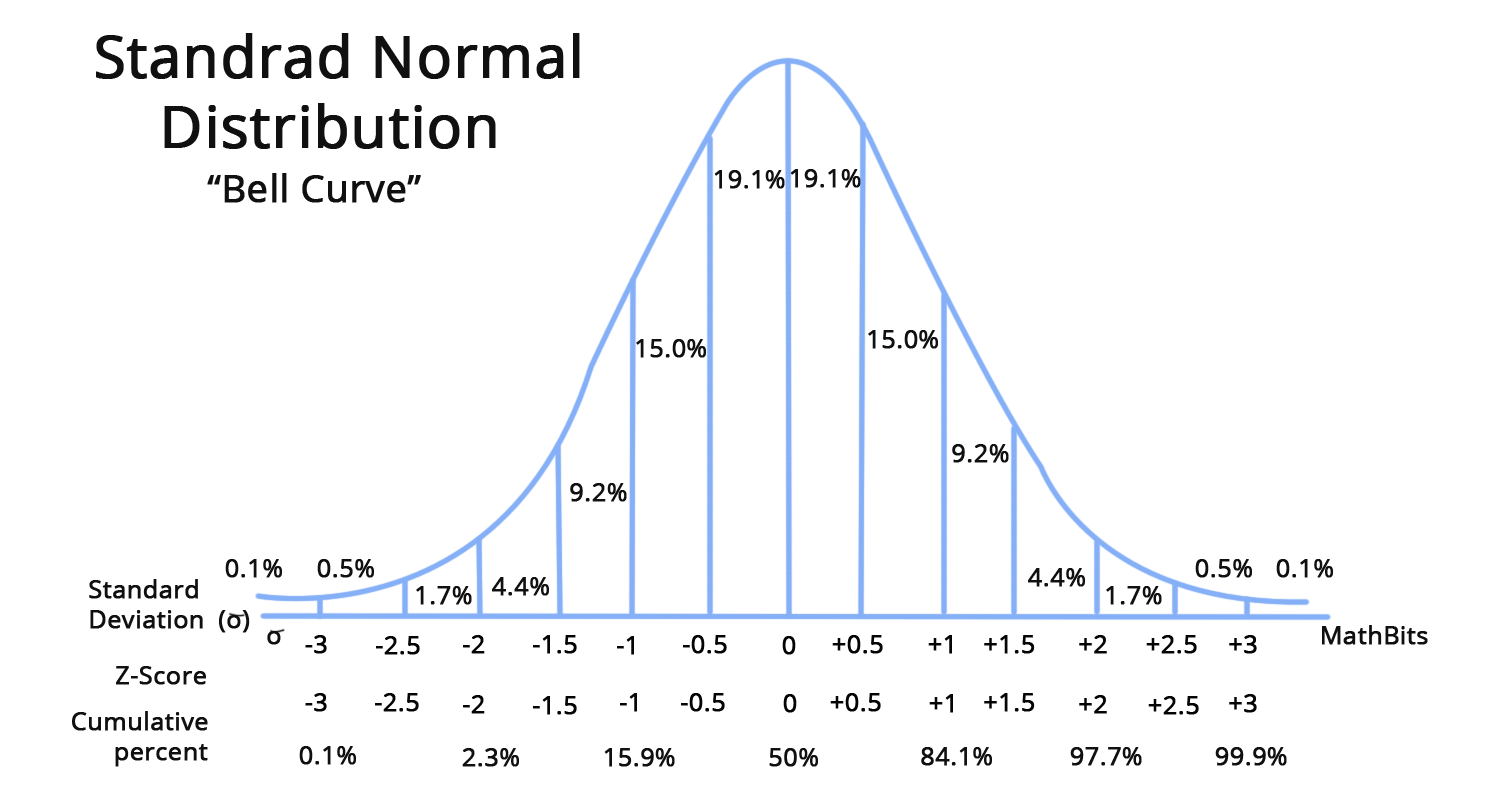

In [93]:
zscore = abs(titanic_df.Age -titanic_df.Age.mean())/titanic_df.Age.std()
zscore

,Age
PassengerId,
1,0.707107
2,0.707107


In [94]:
# Hypothesis tesing
# Z-score